In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.decomposition import PCA


In [2]:
X=pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/preprocessed_features.csv')
y=pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/target_binary.csv')

In [3]:
# Cell 2: PCA fit
pca = PCA(n_components=min( X.shape[1], X.shape[0] ))
X_pca = pca.fit_transform(X)

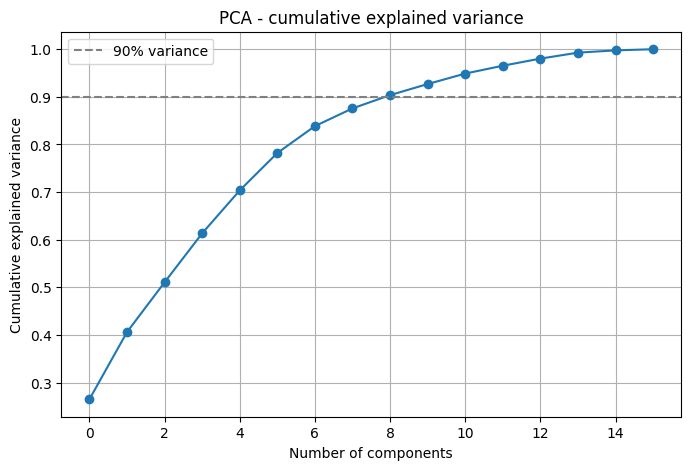

In [5]:
# Plot explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(cumvar, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.title("PCA - cumulative explained variance")
plt.axhline(0.90, linestyle='--', color='grey', label='90% variance')
plt.legend()
plt.show()


In [6]:
# Cell 3: Choose n_components (example choose components explaining >=90%)
n_components = int(np.searchsorted(cumvar, 0.90) + 1)
print("Components to reach 90% variance:", n_components)


Components to reach 90% variance: 9


In [7]:
# Save PCA-transformed dataset (optional)
pca_n = PCA(n_components=n_components)
X_pca_n = pca_n.fit_transform(X)
pd.DataFrame(X_pca_n, columns=[f"pc{i+1}" for i in range(n_components)]).to_csv("/content/drive/MyDrive/datasets/Heart_Disease_Project/X_pca.csv", index=False)
joblib.dump(pca_n, "/content/drive/MyDrive/datasets/Heart_Disease_Project/pca_model.pkl")

['/content/drive/MyDrive/datasets/Heart_Disease_Project/pca_model.pkl']